<a href="https://colab.research.google.com/github/Kunj-7007/AI_ML_Workshop_LDRP/blob/day2/ML_RandomForest_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier # Added for Random Forest
from sklearn.metrics import accuracy_score, confusion_matrix , classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

In [ ]:
#Load the dataset
data=pd.read_csv('/content/agricultural sustainability.csv')
#display first few rows
print (data.head())
print(data.shape)

   soil_health   crop_yield  water_usage  carbon_footprint  fertilizer_use  \
0     0.374540  6778.284815   964.057410        126.020778      226.809659   
1     0.950714  1757.259685  4561.488080        175.365653       88.134761   
2     0.731994  2454.658427  2773.635676        129.654718      194.072090   
3     0.598658  9086.987697  4219.058597         89.916140      201.678762   
4     0.156019  6457.861537  1940.223205        104.286142      156.032668   

   sustainability  
0               0  
1               0  
2               0  
3               0  
4               0  
(200, 6)


In [ ]:
#Define features and target variable
x=data[['soil_health','crop_yield','water_usage','carbon_footprint','fertilizer_use']]
y=data['sustainability']  #1 for effective reduction , 0 otherwise

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [ ]:
model=RandomForestClassifier()
model.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
y_pred=model.predict(x_test)
print(y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 1]


In [ ]:
#Accurracy
accuracy_score=accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy_score}")

Accuracy: 0.925


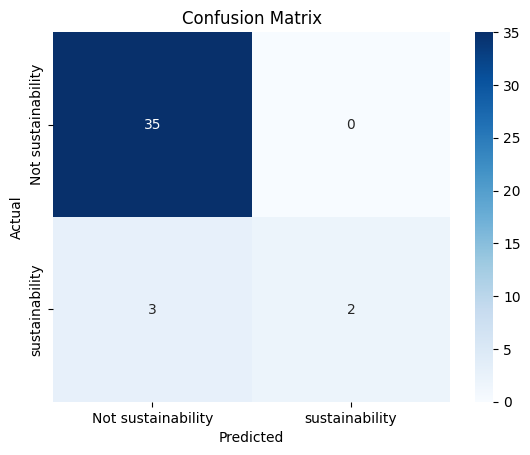

In [ ]:
#Confusion matirx
conf_matrix=confusion_matrix(y_test,y_pred)
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Not sustainability','sustainability'],
            yticklabels=['Not sustainability','sustainability']
            )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Classification report
print (classification_report(y_test,y_pred , target_names=['Not sustainability','sustainability']))

                    precision    recall  f1-score   support

Not sustainability       0.92      1.00      0.96        35
    sustainability       1.00      0.40      0.57         5

          accuracy                           0.93        40
         macro avg       0.96      0.70      0.77        40
      weighted avg       0.93      0.93      0.91        40



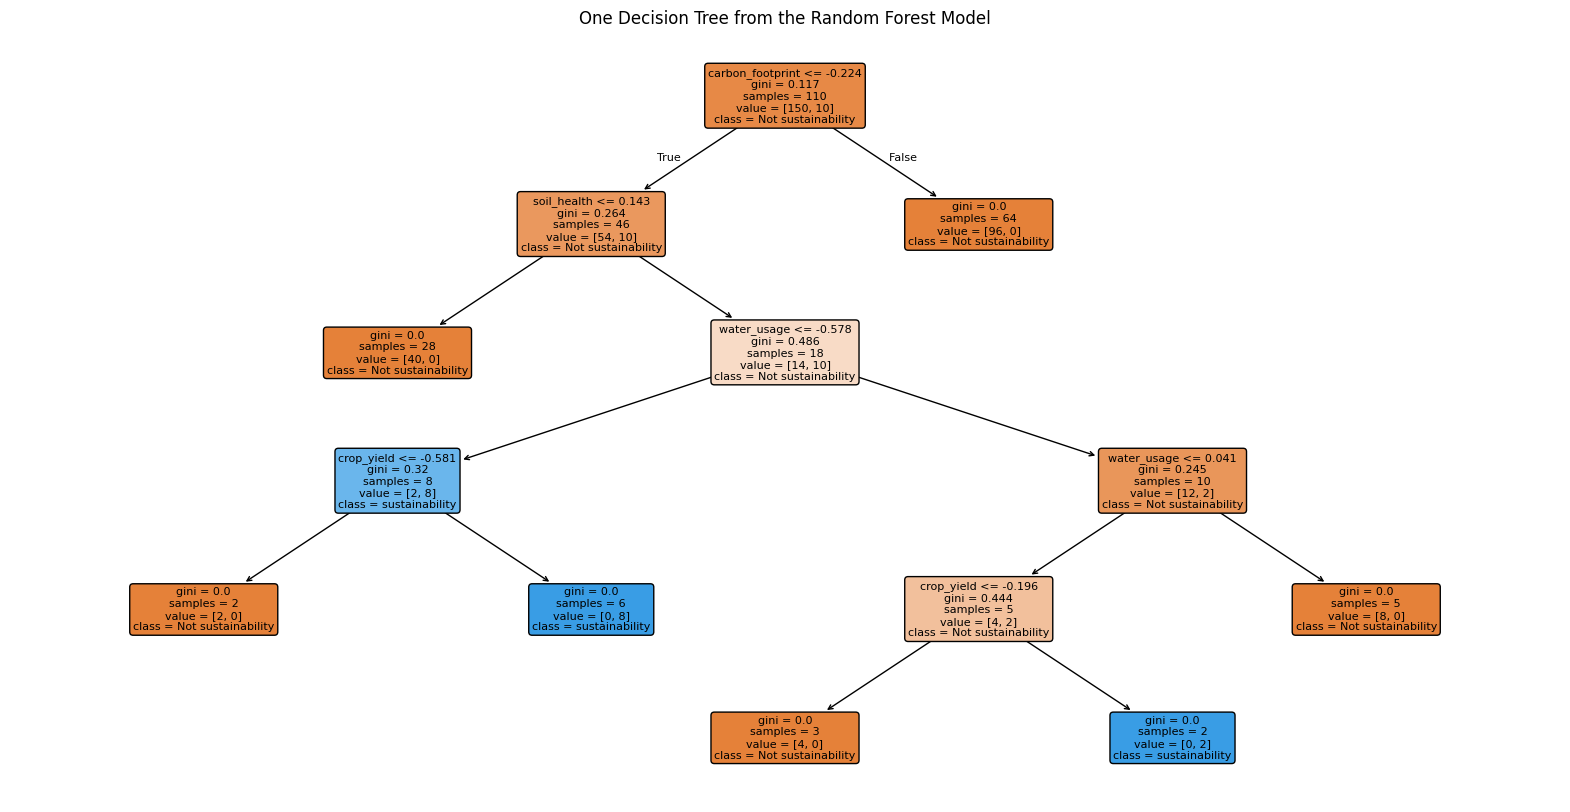

In [ ]:
# Extract one tree from the Random Forest
estimator = model.estimators_[0] # You can change the index to view a different tree

plt.figure(figsize=(20,10))
plot_tree(estimator,
          feature_names=x.columns,
          class_names=['Not sustainability', 'sustainability'],
          filled=True,
          impurity=True,
          rounded=True,
          fontsize=8)
plt.title('One Decision Tree from the Random Forest Model')
plt.show()